In [1]:
import pandas as pd 
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,precision_score,recall_score,roc_auc_score
import xgboost as xgb

In [2]:
df=pd.read_csv("healthcare_fraud_detection.csv")
df

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,P0289,C0009995,79,Male,E78.5,71046,590.19,205.00,Private,2024-09-24,2,115,Internal Medicine,PA,Approved,1,2,Inpatient,1,3.0
9996,P0248,C0009996,66,Male,K21.9,93000,219.73,191.89,Self-Pay,2023-01-04,6,73,Orthopedics,IL,Approved,0,5,Inpatient,0,6.0
9997,P0122,C0009997,43,Female,F41.9,99213,505.24,447.94,Medicare,2024-06-30,6,59,Neurology,OH,Rejected,0,5,Emergency,1,0.0
9998,P0072,C0009998,39,Female,I10,93000,564.25,507.18,Medicare,2022-03-15,8,55,Cardiology,TX,Pending,0,5,Emergency,0,6.0


In [3]:
df['Procedure_Code'].unique()

array([36415, 99213, 93000, 85025, 80053, 97110, 71046, 87086, 99214])

In [4]:
df['Diagnosis_Code'].unique()

array(['I25.10', 'E11.9', 'J06.9', 'I10', 'M54.5', 'E78.5', 'K21.9',
       'F41.9', 'N39.0', 'J18.9'], dtype=object)

In [5]:
df['Insurance_Type'].unique()

array(['Medicaid', 'Self-Pay', 'Private', 'Medicare', nan], dtype=object)

In [6]:
df["Chronic_Condition_Flag"].value_counts(normalize=True)

Chronic_Condition_Flag
0    0.708
1    0.292
Name: proportion, dtype: float64

In [7]:
df["Is_Fraud"].value_counts(normalize=True)

Is_Fraud
0    0.9171
1    0.0829
Name: proportion, dtype: float64

In [8]:
df['Patient_State'].unique()

array(['NY', 'IL', 'TX', 'PA', 'CA', 'OH', 'FL', 'GA'], dtype=object)

In [9]:
df['Insurance_Type']=df['Insurance_Type'].fillna("Unknown")
df['Provider_Specialty']=df['Provider_Specialty'].fillna("Unknown")
df['Prior_Visits_12m']=df['Prior_Visits_12m'].fillna(df['Prior_Visits_12m'].median())

In [10]:
df.isnull().sum()

Provider_ID                              0
Claim_ID                                 0
Patient_Age                              0
Patient_Gender                           0
Diagnosis_Code                           0
Procedure_Code                           0
Claim_Amount                             0
Approved_Amount                          0
Insurance_Type                           0
Claim_Submission_Date                    0
Days_Between_Service_and_Claim           0
Number_of_Claims_Per_Provider_Monthly    0
Provider_Specialty                       0
Patient_State                            0
Claim_Status                             0
Is_Fraud                                 0
Length_of_Stay                           0
Visit_Type                               0
Chronic_Condition_Flag                   0
Prior_Visits_12m                         0
dtype: int64

In [11]:
df.head(5)

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [12]:
df=df.drop(columns=['Provider_ID','Claim_ID','Claim_Submission_Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Patient_Age                            10000 non-null  int64  
 1   Patient_Gender                         10000 non-null  object 
 2   Diagnosis_Code                         10000 non-null  object 
 3   Procedure_Code                         10000 non-null  int64  
 4   Claim_Amount                           10000 non-null  float64
 5   Approved_Amount                        10000 non-null  float64
 6   Insurance_Type                         10000 non-null  object 
 7   Days_Between_Service_and_Claim         10000 non-null  int64  
 8   Number_of_Claims_Per_Provider_Monthly  10000 non-null  int64  
 9   Provider_Specialty                     10000 non-null  object 
 10  Patient_State                          10000 non-null  object 
 11  Cla

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [14]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Is_Fraud']),df['Is_Fraud'],test_size=0.3,stratify=df['Is_Fraud'],random_state=42)

In [15]:
x_train.columns

Index(['Patient_Age', 'Patient_Gender', 'Diagnosis_Code', 'Procedure_Code',
       'Claim_Amount', 'Approved_Amount', 'Insurance_Type',
       'Days_Between_Service_and_Claim',
       'Number_of_Claims_Per_Provider_Monthly', 'Provider_Specialty',
       'Patient_State', 'Claim_Status', 'Length_of_Stay', 'Visit_Type',
       'Chronic_Condition_Flag', 'Prior_Visits_12m'],
      dtype='object')

In [16]:
x_train

,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
3909,51,Male,F41.9,99213,301.16,230.05,Private,17,67,Cardiology,FL,Pending,2,Outpatient,0,4.0
2582,77,Female,E11.9,80053,504.58,478.35,Medicaid,18,69,Internal Medicine,PA,Approved,0,Inpatient,0,2.0
3944,58,Male,K21.9,99213,956.52,735.62,Medicaid,24,62,Cardiology,FL,Rejected,5,Inpatient,0,3.0
4712,60,Female,K21.9,36415,863.32,748.87,Self-Pay,28,55,Orthopedics,OH,Approved,5,Outpatient,0,2.0
3364,36,Male,I10,99214,582.74,510.78,Private,15,76,Pulmonology,PA,Approved,0,Emergency,1,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1745,59,Female,F41.9,99213,525.78,469.04,Medicaid,21,60,Neurology,CA,Approved,1,Inpatient,0,2.0
6424,14,Female,K21.9,99213,535.41,528.35,Self-Pay,23,74,General Practice,TX,Approved,0,Inpatient,0,6.0
9584,61,Male,F41.9,99213,1088.67,902.56,Private,10,74,Orthopedics,NY,Rejected,3,Inpatient,0,6.0
2156,55,Male,E78.5,85025,188.88,183.59,Medicaid,11,67,Internal Medicine,OH,Approved,3,Inpatient,1,2.0


In [17]:
categorical_cols=['Patient_Gender', 'Diagnosis_Code', 'Procedure_Code','Insurance_Type','Provider_Specialty',
       'Patient_State', 'Claim_Status','Visit_Type']

numerical_cols=['Patient_Age','Claim_Amount','Approved_Amount','Days_Between_Service_and_Claim', 'Number_of_Claims_Per_Provider_Monthly','Length_of_Stay','Prior_Visits_12m']

In [18]:
categorical_pipeline=Pipeline(steps=[
    ("Imputer",SimpleImputer(strategy='constant',fill_value='Unknown')),
    ('Ohe',OneHotEncoder(handle_unknown='ignore',drop='first'))
])

numerical_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('Scaler',StandardScaler())
])

In [19]:
perprocessor=ColumnTransformer(transformers=[
    ('Cat',categorical_pipeline,categorical_cols),
    ('Num',numerical_pipeline,numerical_cols)
])

In [20]:
x_train_tranformed=perprocessor.fit_transform(x_train)
x_test_tranformed=perprocessor.transform(x_test)

In [21]:
# model training

## Y column is highly imbalanced with claim being fraud = 8% and claim not being fraud = 92%
## Using scale_pos_weight to handle this imbalance

In [22]:
scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()
print(scale_pos_weight)

11.068965517241379


In [23]:
model=xgb.XGBClassifier(scale_pos_weight=scale_pos_weight)

In [24]:
model.fit(x_train_tranformed,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [25]:
y_pred=model.predict(x_test_tranformed)
y_pred_proba = model.predict_proba(x_test_tranformed)[:, 1]

In [26]:

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2751
           1       0.94      0.94      0.94       249

    accuracy                           0.99      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.99      0.99      0.99      3000

[[2735   16]
 [  16  233]]
ROC-AUC: 0.9974729890116628


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

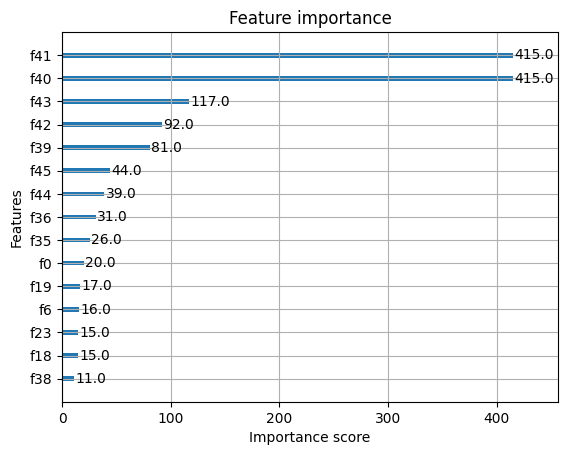

In [27]:
import xgboost as xgb
xgb.plot_importance(model, max_num_features=15)

In [28]:
importances = model.feature_importances_
feature_names = perprocessor.get_feature_names_out()
pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

Num__Days_Between_Service_and_Claim    0.647768
Cat__Claim_Status_Pending              0.067273
Cat__Claim_Status_Rejected             0.038021
Cat__Procedure_Code_71046              0.028264
Num__Claim_Amount                      0.026224
Num__Approved_Amount                   0.025488
Cat__Provider_Specialty_Neurology      0.021574
Cat__Patient_State_IL                  0.011638
Cat__Provider_Specialty_Pulmonology    0.011637
Cat__Provider_Specialty_Unknown        0.011554
Cat__Procedure_Code_85025              0.009530
Cat__Procedure_Code_87086              0.007906
Cat__Insurance_Type_Self-Pay           0.007227
Cat__Patient_State_NY                  0.006883
Cat__Diagnosis_Code_J18.9              0.006716
dtype: float32

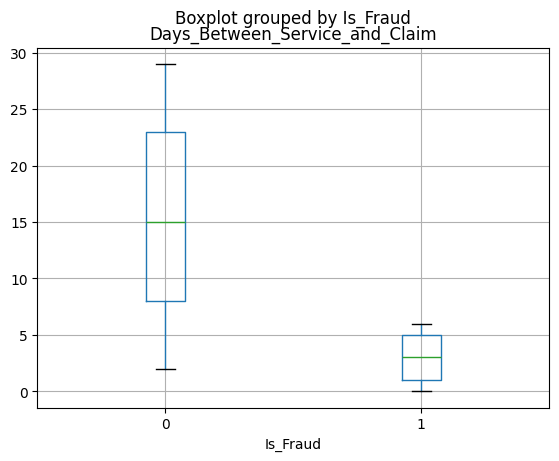

In [29]:
import matplotlib.pyplot as plt

df.boxplot(column="Days_Between_Service_and_Claim", by="Is_Fraud")
plt.show()

In [30]:
### our model is overfitting on column Days_Between_Service_and_Claim as it is a synthetic dataset
### lets drop this column and make sure our model learns actual pattern

In [31]:
update_numerical_cols=['Patient_Age','Claim_Amount','Approved_Amount', 'Number_of_Claims_Per_Provider_Monthly','Length_of_Stay','Prior_Visits_12m']
updated_categorical_cols=['Patient_Gender', 'Diagnosis_Code', 'Procedure_Code','Insurance_Type','Provider_Specialty',
       'Patient_State','Visit_Type']

In [32]:
perprocessor_2=ColumnTransformer(transformers=[
    ('Cat',categorical_pipeline,updated_categorical_cols),
    ('Num',numerical_pipeline,update_numerical_cols)
])

In [33]:
x_train=x_train.drop(columns=['Days_Between_Service_and_Claim','Claim_Status'])
x_test=x_test.drop(columns=['Days_Between_Service_and_Claim','Claim_Status'])

In [34]:
x_train_tranformed=perprocessor_2.fit_transform(x_train)
x_test_tranformed=perprocessor_2.transform(x_test)

In [35]:
model2=xgb.XGBClassifier(scale_pos_weight=scale_pos_weight)
model2.fit(x_train_tranformed,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
y_pred=model2.predict(x_test_tranformed)
y_pred_proba = model2.predict_proba(x_test_tranformed)[:, 1]

In [37]:

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2751
           1       0.93      0.84      0.88       249

    accuracy                           0.98      3000
   macro avg       0.96      0.91      0.93      3000
weighted avg       0.98      0.98      0.98      3000

[[2735   16]
 [  41  208]]
ROC-AUC: 0.9826496097074594


In [38]:
importances = model2.feature_importances_
feature_names = perprocessor_2.get_feature_names_out()
pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

Num__Claim_Amount                  0.179151
Num__Approved_Amount               0.126018
Cat__Diagnosis_Code_N39.0          0.054668
Cat__Procedure_Code_99214          0.051635
Cat__Patient_State_IL              0.036647
Cat__Procedure_Code_87086          0.031536
Cat__Diagnosis_Code_F41.9          0.027295
Cat__Provider_Specialty_Unknown    0.026424
Cat__Diagnosis_Code_M54.5          0.024520
Cat__Patient_State_TX              0.022170
Cat__Procedure_Code_71046          0.021178
Cat__Patient_State_FL              0.020679
Cat__Diagnosis_Code_E78.5          0.020570
Cat__Insurance_Type_Unknown        0.020121
Cat__Diagnosis_Code_J18.9          0.019334
dtype: float32

In [39]:
import joblib
joblib.dump(model2,"fruad_model.pkl")
joblib.dump(perprocessor_2, "fraud_preprocessor.pkl")

['fraud_preprocessor.pkl']

### TESTING THE SAVED MODEL

In [40]:
test_model=joblib.load("fruad_model.pkl")
test_preprocess=joblib.load('fraud_preprocessor.pkl')

In [41]:
def predict_fraud_risk(claim:dict):
    claim_df=pd.DataFrame([claim])
    claim_transformed=test_preprocess.transform(claim_df)
    predict=test_model.predict(claim_transformed)
    proba = test_model.predict_proba(claim_transformed)[0][1]
    if predict==0:
        predict='No'
    else:
        predict="Yes"
    return {"Fraud":predict,
        "fraud_probability": round(float(proba), 4)
    }

In [42]:
def get_top_features(n=5):
    importances = test_model.feature_importances_
    feature_names = test_preprocess.get_feature_names_out()
    return pd.Series(importances, index=feature_names).sort_values(ascending=False).head(n).to_dict()

In [43]:
sample=x_test.iloc[0].to_dict()
print(sample)

{'Patient_Age': 48, 'Patient_Gender': 'Female', 'Diagnosis_Code': 'N39.0', 'Procedure_Code': 99214, 'Claim_Amount': 243.5, 'Approved_Amount': 196.32, 'Insurance_Type': 'Medicare', 'Number_of_Claims_Per_Provider_Monthly': 71, 'Provider_Specialty': 'Pulmonology', 'Patient_State': 'TX', 'Length_of_Stay': 5, 'Visit_Type': 'Outpatient', 'Chronic_Condition_Flag': 0, 'Prior_Visits_12m': 1.0}


In [44]:
result=predict_fraud_risk(sample)
print(result)

{'Fraud': 'No', 'fraud_probability': 0.0005}


In [45]:
get_top_features()

{'Num__Claim_Amount': 0.17915084958076477,
 'Num__Approved_Amount': 0.12601815164089203,
 'Cat__Diagnosis_Code_N39.0': 0.054668448865413666,
 'Cat__Procedure_Code_99214': 0.051634594798088074,
 'Cat__Patient_State_IL': 0.03664673864841461}

In [46]:
# In training notebook
sample_claims = x_test.iloc[:5].to_dict(orient="records")
import json
with open("sample_claims.json", "w") as f:
    json.dump(sample_claims, f, indent=2, default=str)